In [4]:
library(Seurat)
#library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### load all samples

In [4]:
matrix_list <- read.table('matrix9.list',header=T)

In [5]:
head(matrix_list)

,sample_id,path
,<chr>,<chr>
1,SC005,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC005/outs/filtered_feature_bc_matrix/
2,SC008,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC008/outs/filtered_feature_bc_matrix/
3,SC015,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC015/outs/filtered_feature_bc_matrix/
4,SC017,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC017T/outs/filtered_feature_bc_matrix/
5,SC027,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC027/outs/filtered_feature_bc_matrix/
6,SC031,/disk1/minglu/single-cell/sc_gastric/240322_Duo/01.mapping/SC031/outs/filtered_feature_bc_matrix/


### assign sample name to counts obj 

In [6]:
count_list = list()
for(i in 1:nrow(matrix_list)){
    counts.data <- Read10X(data.dir = matrix_list$path[i])
    ### add sample name to cell barcodes
    counts.data %>% colnames() %>% paste0(.,'-',matrix_list$sample_id[i]) -> colnames
    colnames(counts.data) <- colnames
    ### make a list
    count_list = append(count_list,counts.data)
}
### add sample name to list
names(count_list) <- matrix_list$sample_id

### assign the sample names to metadata

In [7]:
GCA_obj <- CreateSeuratObject(counts = count_list)

In [8]:
### get the sample name from the cell barcode and assign it to metadata
GCA_obj@meta.data %>% rownames() %>% str_split('-') %>% map_chr(last) -> GCA_obj$sample

In [9]:
GCA_obj[["percent.mt"]] <- PercentageFeatureSet(GCA_obj, pattern = "^MT-")

In [10]:
head(GCA_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt
,<fct>,<dbl>,<dbl>,<chr>,<dbl>
AAACCCAAGACTCTTG-1-SC005,SeuratProject,1864,1114,SC005,4.560086
AAACCCAAGAGCATTA-1-SC005,SeuratProject,4430,2242,SC005,1.602709
AAACCCAAGCAACTTC-1-SC005,SeuratProject,2869,825,SC005,1.707912
AAACCCAAGCGTTGTT-1-SC005,SeuratProject,1095,732,SC005,2.557078
AAACCCAAGTACTGGG-1-SC005,SeuratProject,1236,808,SC005,3.236246
AAACCCACAAAGACGC-1-SC005,SeuratProject,503,359,SC005,7.355865


### cell number before filter

In [11]:
GCA_obj@meta.data %>% dplyr::count(sample) -> Total_cellnumber

In [12]:
Total_cellnumber  %>% head()

,sample,n
,<chr>,<int>
1,SC005,8376
2,SC008,5223
3,SC015,7980
4,SC017,7909
5,SC027,14554
6,SC031,7360


In [13]:
options(repr.plot.height=6,repr.plot.width=6)
p_total_bar <- ggplot(data =Total_cellnumber ) + geom_bar(aes(x=sample,y=n),fill="#018571",stat='identity')+theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'),
          axis.text.y=element_text(color="black"))+ylab("Total cell number")+xlab('')

In [14]:
ggsave(filename = "Total_cell_number.pdf",plot = p_total_bar,width = 6,height = 6)

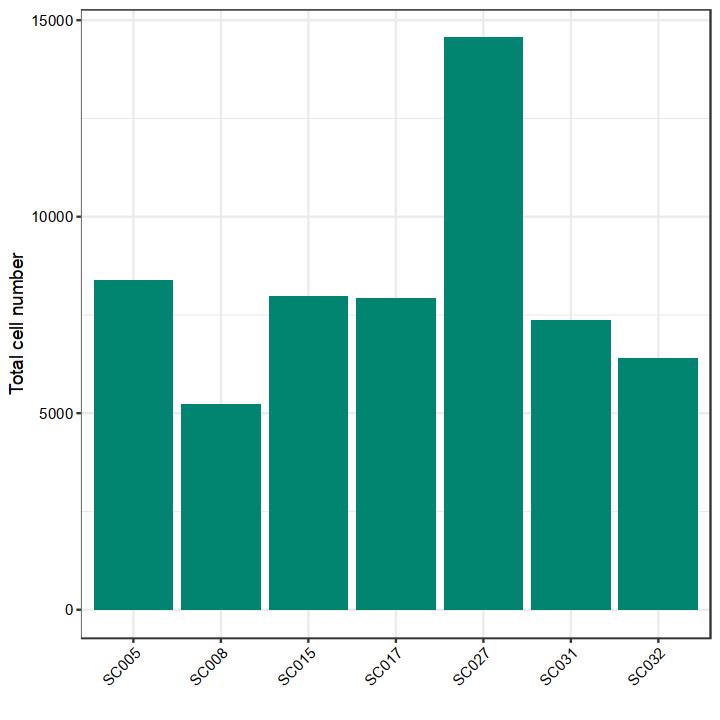

In [15]:
p_total_bar

### Visualize QC metrics as a violin plot

In [16]:
#options(repr.plot.height=6,repr.plot.width=6)
#for(i in 1:nrow(matrix_list)){
#    samplename = matrix_list$sample_id[i]
#  p_temp <- VlnPlot(subset(x = GCA_obj, subset = sample == samplename), pt.size = 0,
#        features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), 
#                      ncol = 3,layer = paste0('counts.',samplename))
#  ggsave(filename = paste0("01.VlnPlot/",samplename,"vlnplots.pdf"),plot = p_temp,width = 6,height = 6)
#}

In [ ]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_nFreature = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
            features = c("nFeature_RNA"),  ncol = 1)+geom_hline(yintercept = c(500,7000),linetype = "dashed")

In [ ]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_nCount = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
        features = c("nCount_RNA"),  ncol = 1)+geom_hline(yintercept = c(100,50000),linetype = "dashed")+ylim(c(0,100000))

In [ ]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_MT = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
        features = c("percent.mt"),  ncol = 1)+geom_hline(yintercept = c(0,20),linetype = "dashed")

In [ ]:
ggsave(filename = paste0("01.VlnPlot/p_vln_nFeature.pdf"),plot = p_vln_nFreature,width = 6,height =8)
ggsave(filename = paste0("01.VlnPlot/p_vln_nCount.pdf"),plot = p_vln_nCount,width = 6,height =8)
ggsave(filename = paste0("01.VlnPlot/p_vln_MT.pdf"),plot = p_vln_MT,width = 6,height =8)

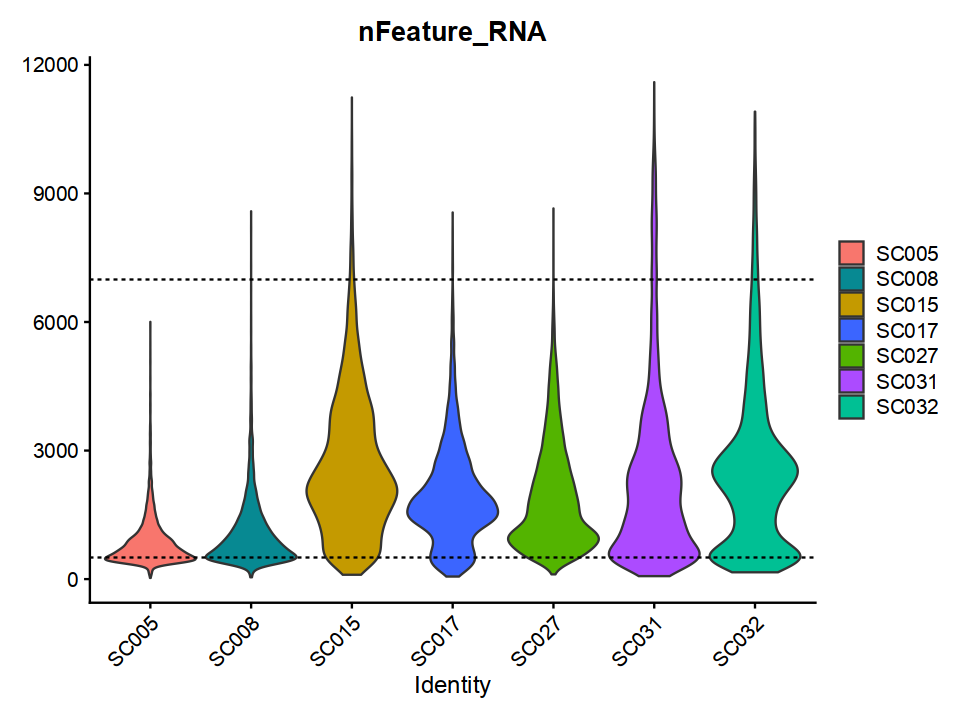

In [21]:
p_vln_nFreature

Warning message:
“Removed 75 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


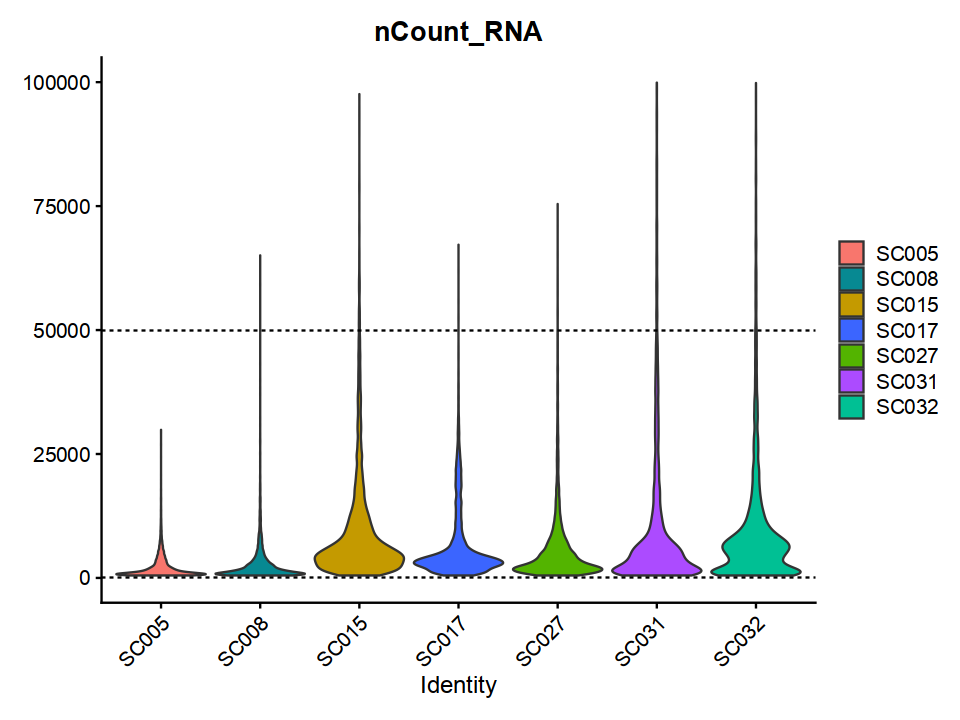

In [22]:
p_vln_nCount

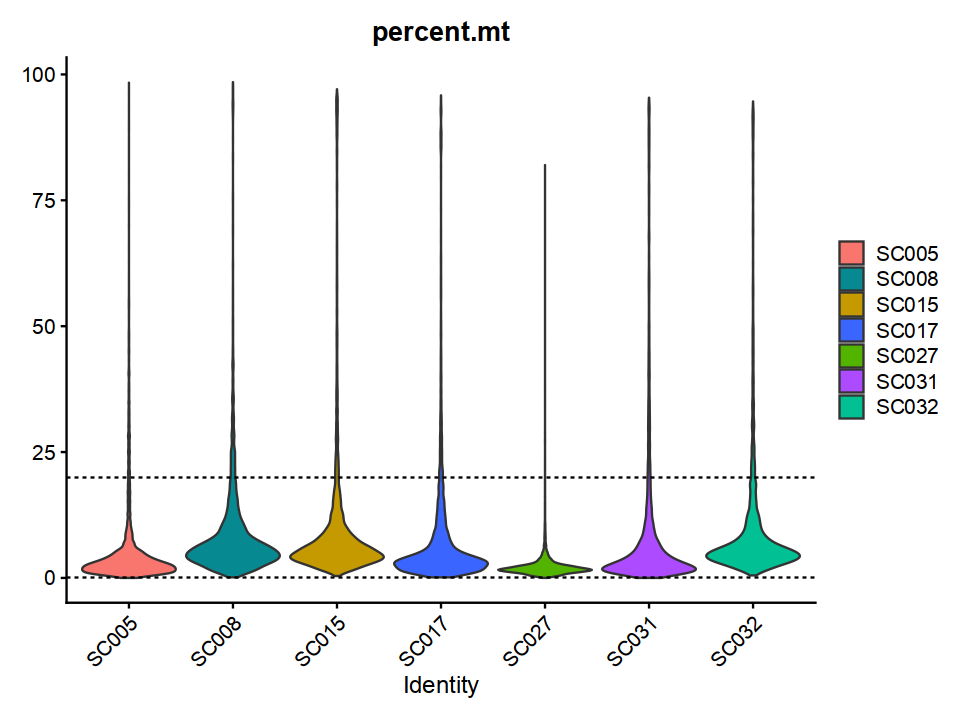

In [23]:
p_vln_MT

### Do filtering

In [ ]:
GCA_obj_subset <- subset(GCA_obj,subset = nFeature_RNA >= 500 & nFeature_RNA <= 7000 & 
                         percent.mt <= 20 & nCount_RNA >= 100 & nCount_RNA <= 50000)

In [14]:
GCA_obj_subset@meta.data %>% dplyr::count(sample) -> Filtered_cellnumber

In [15]:
options(repr.plot.height=6,repr.plot.width=6)
p_filtered_bar <- ggplot(data = Filtered_cellnumber) + geom_bar(aes(x=sample,y=n),fill="#018571",stat='identity')+theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'),
          axis.text.y=element_text(color="black"))+ylab("Total cell number")+xlab('')

In [16]:
ggsave(filename = "Filtered_cell_number.pdf",plot = p_filtered_bar,width = 6,height = 6)

### Do normalization and PCA

In [ ]:
GCA_obj_subset <- NormalizeData(GCA_obj_subset)

In [ ]:
GCA_obj_subset <- FindVariableFeatures(GCA_obj_subset)

In [30]:
GCA_obj_subset <- ScaleData(GCA_obj_subset)

Centering and scaling data matrix



In [ ]:
GCA_obj_subset <- RunPCA(GCA_obj_subset)

### Do intergration

In [152]:
GCA_obj_subset <- IntegrateLayers(object = GCA_obj_subset, method = CCAIntegration,
                                  orig.reduction = "pca",new.reduction = "integrated.cca",verbose = FALSE)

In [ ]:
# re-join layers after integration
GCA_obj_subset[["RNA"]] <- JoinLayers(GCA_obj_subset[["RNA"]])

In [18]:
GCA_obj_subset <- FindNeighbors(GCA_obj_subset, reduction = "umap", dims = 1:2)

Computing nearest neighbor graph

Computing SNN



In [23]:
GCA_obj_subset <- FindClusters(GCA_obj_subset, resolution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 47446
Number of edges: 1550313

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9564
Number of communities: 27
Elapsed time: 43 seconds


In [24]:
GCA_obj_subset <- RunUMAP(GCA_obj_subset, dims = 1:30, reduction = "integrated.cca")

12:03:32 UMAP embedding parameters a = 0.9922 b = 1.112

12:03:32 Read 47446 rows and found 30 numeric columns

12:03:32 Using Annoy for neighbor search, n_neighbors = 30

12:03:32 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:03:53 Writing NN index file to temp file /disk1/pengweixing/tmp/Rtmp4wuvZJ/file99a77cfb66aa

12:03:53 Searching Annoy index using 1 thread, search_k = 3000

12:04:38 Annoy recall = 100%

12:04:39 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:04:47 Initializing from normalized Laplacian + noise (using RSpectra)

12:05:03 Commencing optimization for 200 epochs, with 2294946 positive edges

12:06:24 Optimization finished



In [25]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
p_dim <- DimPlot(GCA_obj_subset, reduction = "umap", group.by = c("seurat_clusters"),label = TRUE,ncol=1)

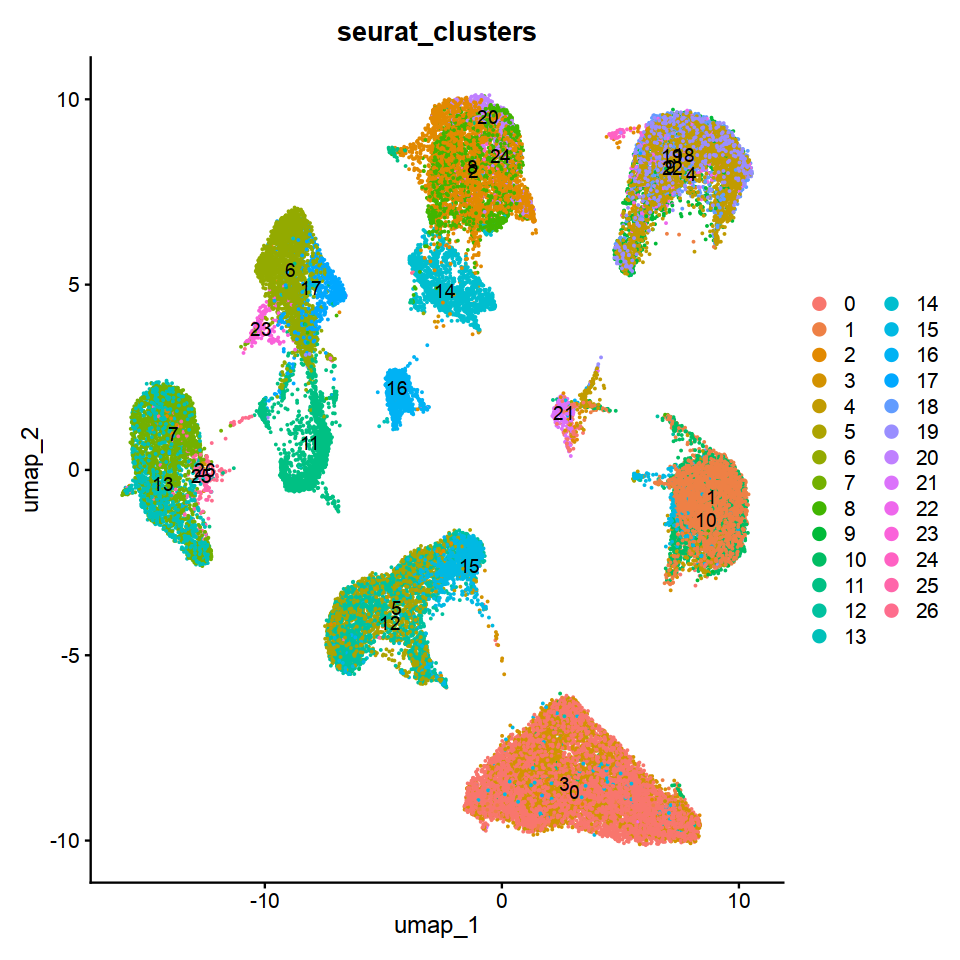

In [26]:
p_dim

In [7]:
options(repr.plot.height=8,repr.plot.width=10)
p_features <- FeaturePlot(GCA_obj_subset, features = c("nCount_RNA","nFeature_RNA","percent.mt"), raster = TRUE,pt.size = 2)

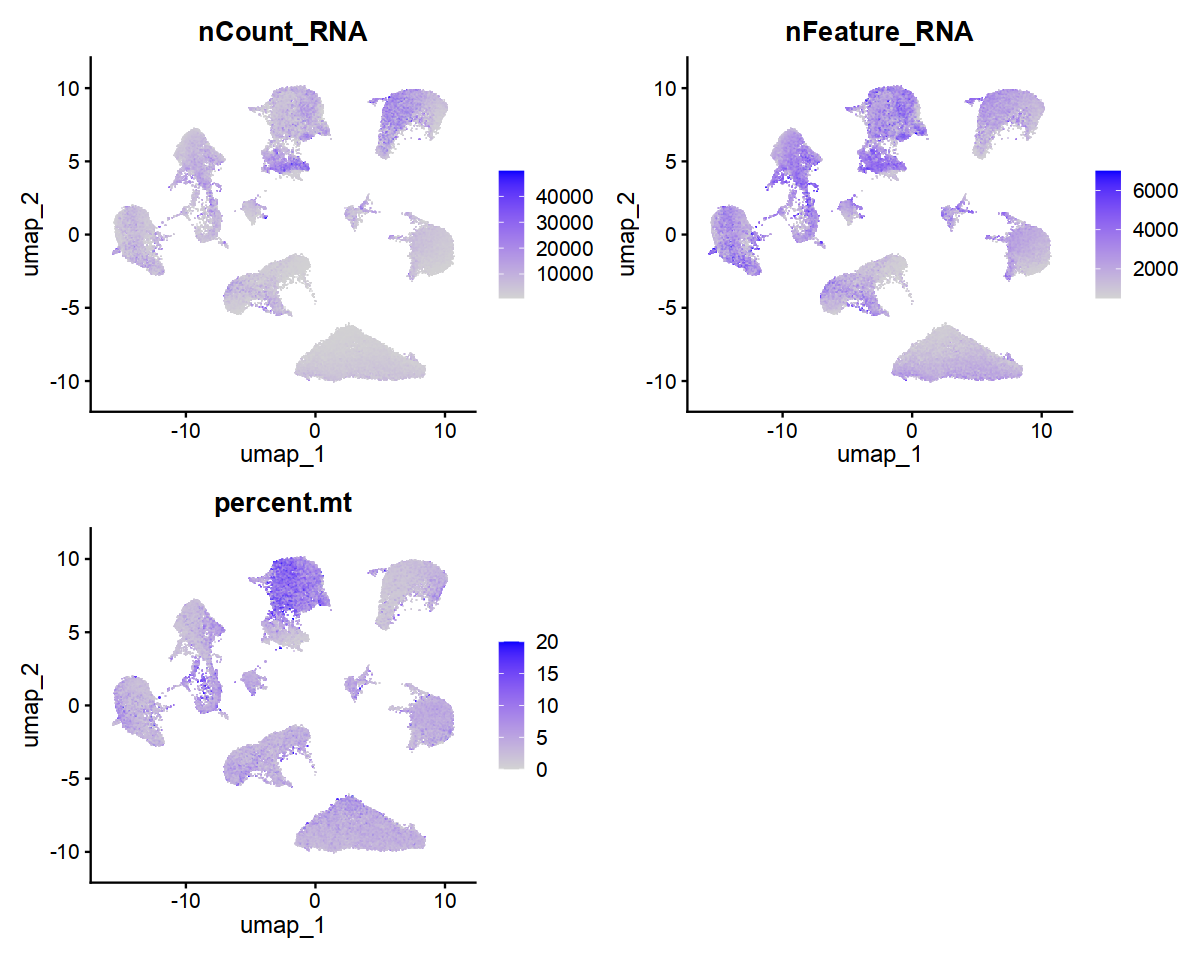

In [8]:
p_features

In [9]:
ggsave(filename = "Cluster.nFeatures.pdf",plot =p_features ,width = 10,height = 8)

In [2]:
packageVersion('optbin')

[1] ‘1.3’

### cell type annotation

In [162]:
sce.pub.Rds <- readRDS("sce.pub.Rds")

In [ ]:
gca.anchors <- FindTransferAnchors(reference = sce.pub.Rds, query = GCA_obj_subset, dims = 1:30,
                                   normalization.method = 'SCT',reference.reduction = "pca")

In [ ]:
predictions <- TransferData(anchorset = gca.anchors, refdata = sce.pub.Rds$compartment, dims = 1:30)

In [174]:
GCA_obj_subset <- AddMetaData(GCA_obj_subset, metadata = predictions)

In [17]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
pdimplot <- DimPlot(GCA_obj_subset, reduction = "umap",group.by = c("predicted.id"),label = TRUE,ncol=1)

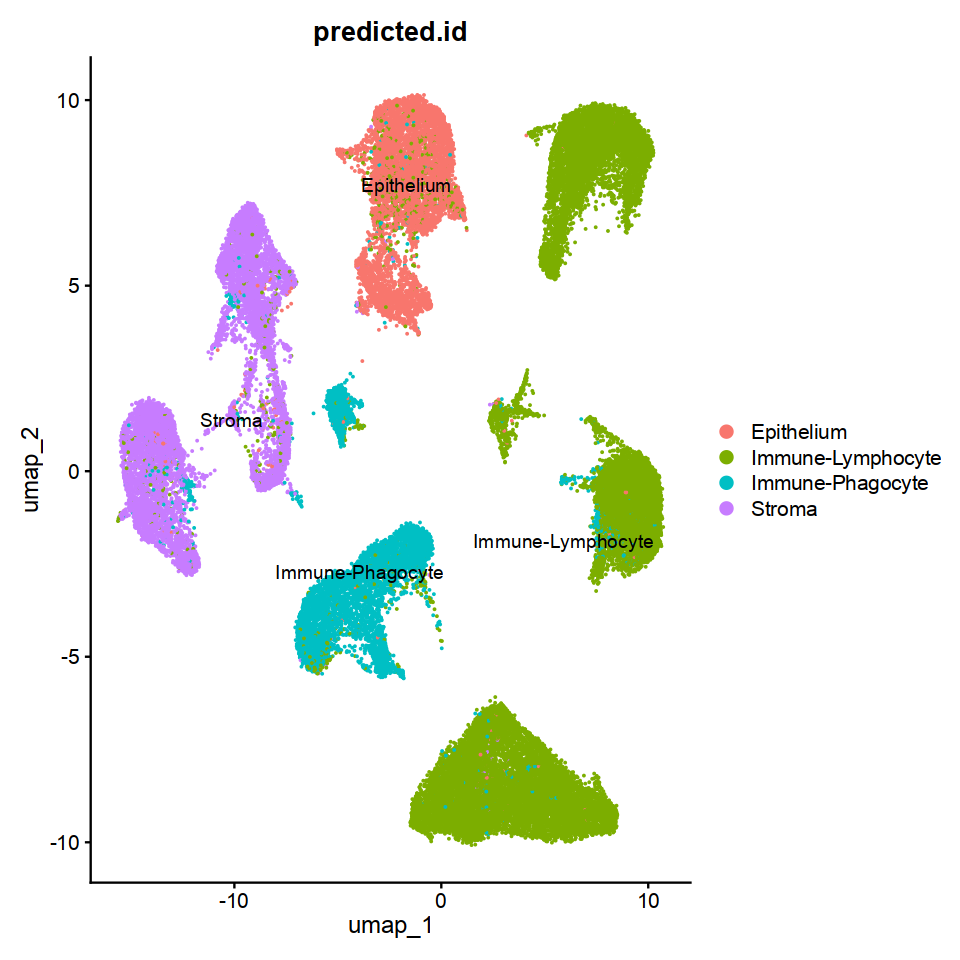

In [18]:
pdimplot

In [19]:
ggsave(filename = "Cluster.Cellcomartments.pdf",plot =pdimplot ,width = 8,height = 8)

### re-assign the name

In [ ]:
GCA_obj_subset@meta.data[,1:8] -> GCA_obj_subset@meta.data

In [ ]:
head(GCA_obj_subset@meta.data)

In [180]:
GCA_obj_subset@meta.data %>% mutate(Maincelltype = case_when(
                          seurat_clusters %in% c(10,5,8,63,14,17,65,46,31) ~ "Epithelium",
                          seurat_clusters %in% c(0,1,25,66,28,11,54,55,56,59,62,64,36,39,7,6,49,15,19,3,30,16,29,23,50,40,42,2,21,21,12,20,9,57) ~ "Lymphocyte",
                          seurat_clusters %in% c(4,18,41,43,33,48,51,24,38) ~ "Phagocyte",
                          seurat_clusters %in% c(32,53,45,13,60,35,67,61,58,37,34,68,22,52,44,27,26,47) ~ "Stroma"
                            )) -> GCA_obj_subset@meta.data

In [29]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
p_dim <- DimPlot(GCA_obj_subset, reduction = "umap", group.by = c("Maincelltype"),
                 ncol=1, raster = TRUE,pt.size = 2)

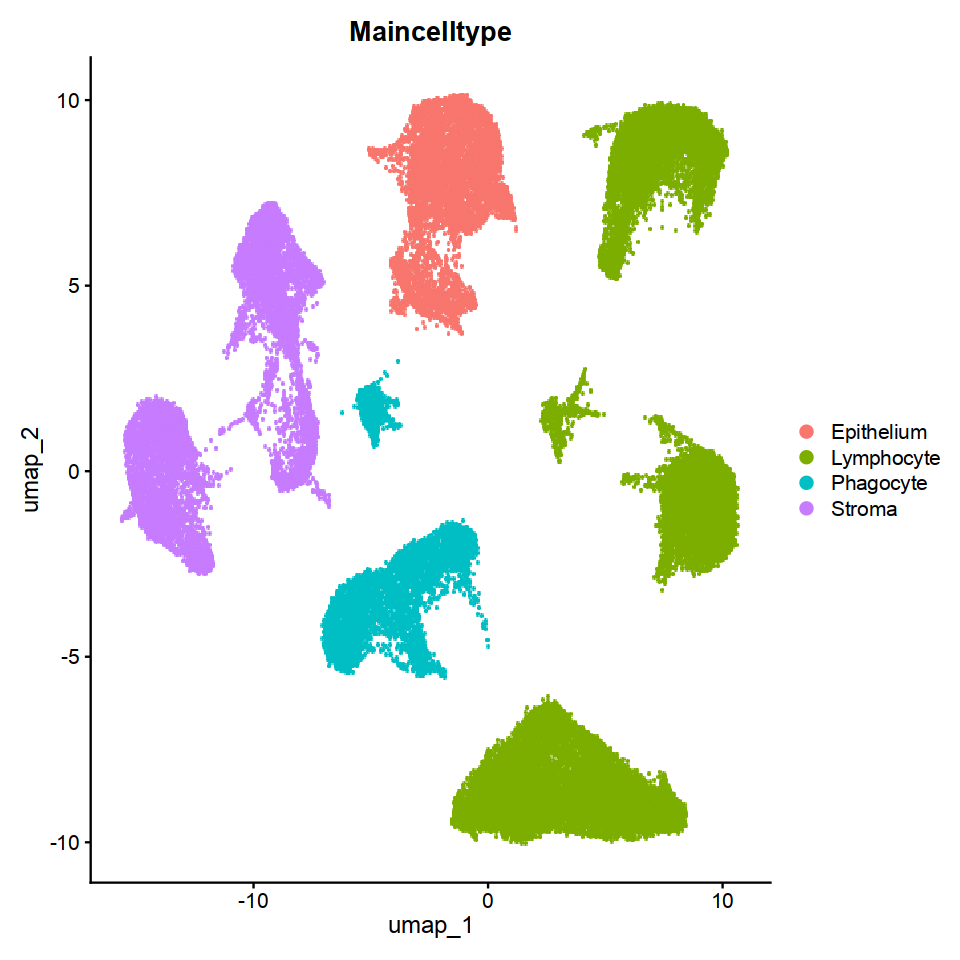

In [30]:
p_dim

In [33]:
ggsave(filename = "GCA_UmapCellcomartments.pdf",plot = p_dim,height =8 ,width = 8)

### cell number for each sample for each cell compartments

In [21]:
GCA_obj_subset@meta.data  %>% dplyr::count(sample,Maincelltype) -> cellcounts

In [22]:
cellcounts %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = Maincelltype) -> distribution_compartment2

In [23]:
options(repr.plot.height=6,repr.plot.width=8)
p_distric <- ggplot(distribution_compartment2, aes(fill=celltype, y=Percentage, x=sample)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")

In [1]:
options(repr.plot.height=6,repr.plot.width=6)
p_distric

ERROR: Error in eval(expr, envir, enclos): object 'p_distric' not found


In [25]:
ggsave(filename = "CellCompartments.barplot.pdf",plot = p_distric,height =6 ,width =8)

In [26]:
# Visualization
p_dim_split <- DimPlot(GCA_obj_subset, reduction = "umap", group.by = c("Maincelltype"),
                       raster = TRUE,pt.size = 2,split.by="sample",ncol=4)

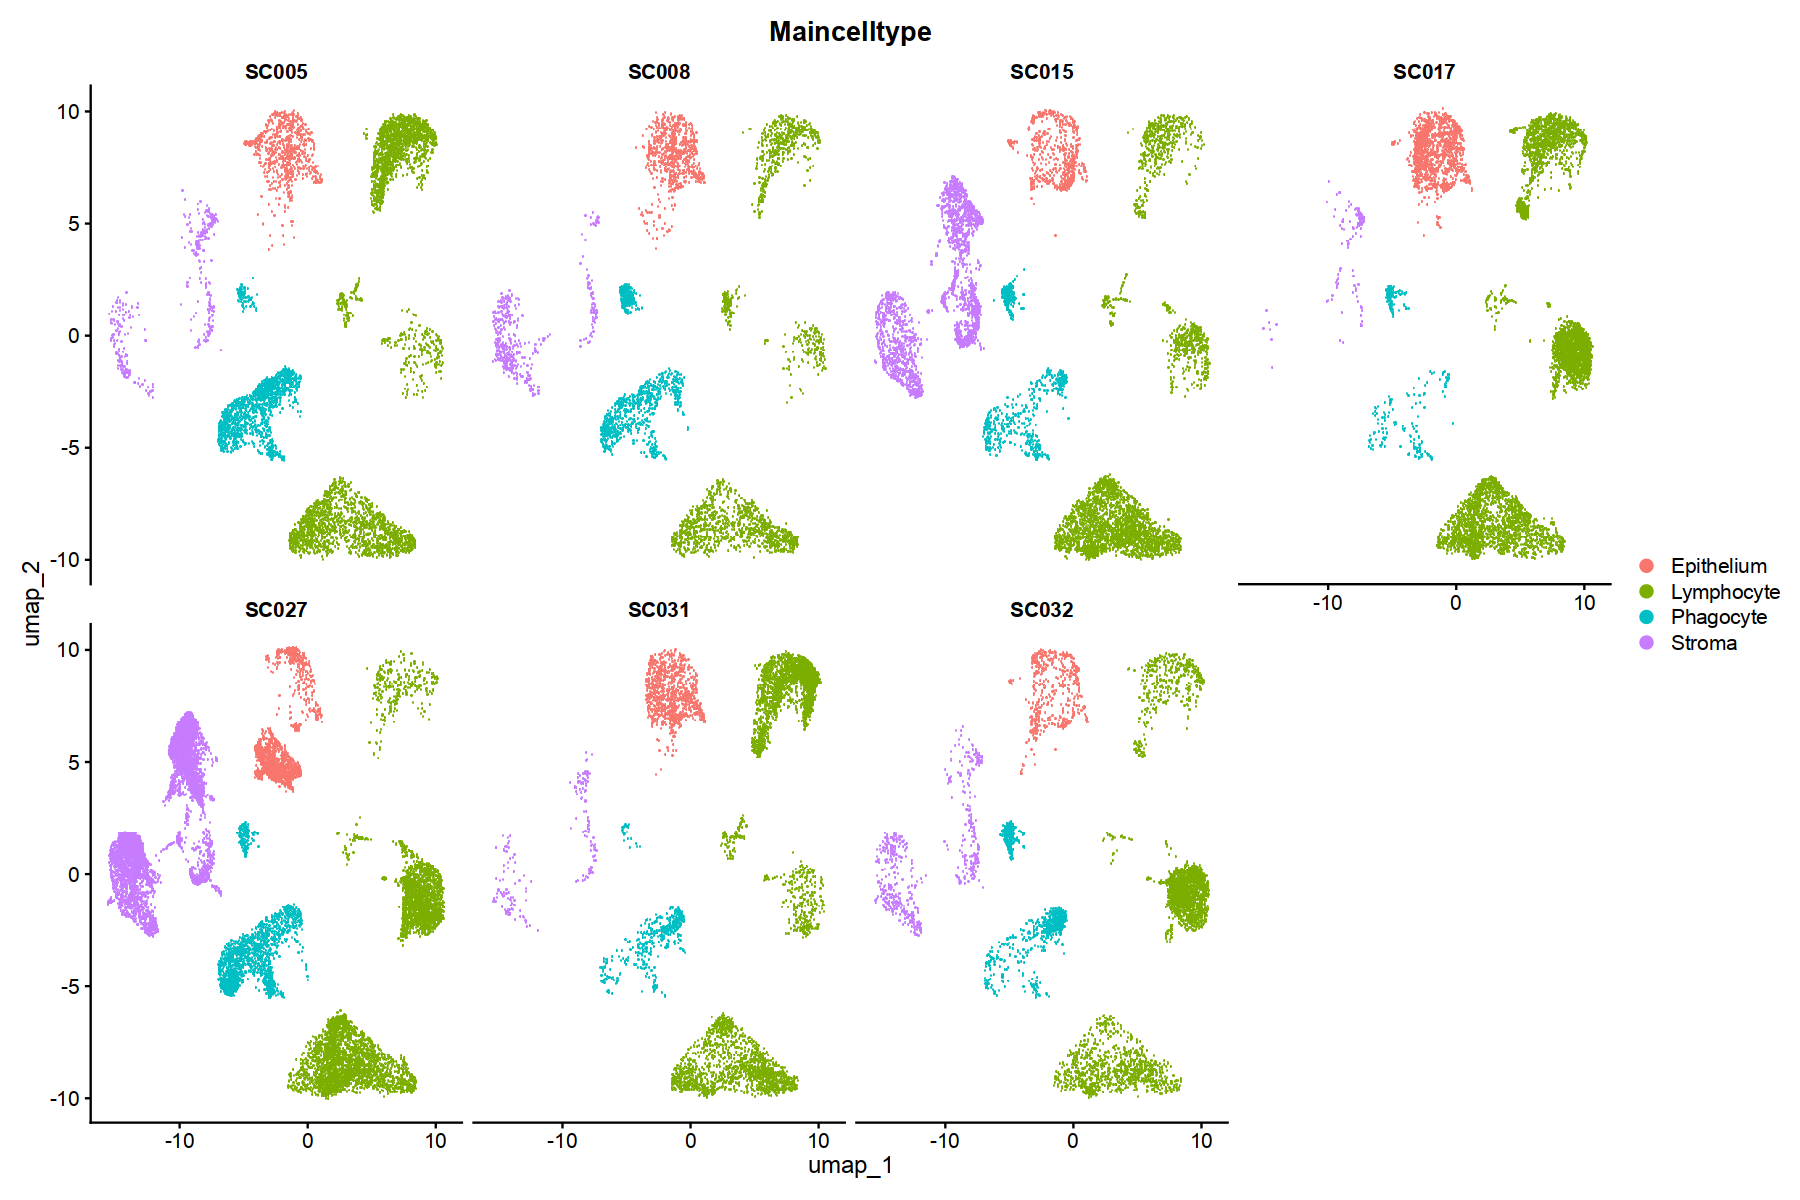

In [27]:
options(repr.plot.height=10,repr.plot.width=15)
p_dim_split

In [28]:
ggsave(filename = "CellCompartments.bySample.pdf",plot = p_dim_split,height =10 ,width =15)

In [ ]:
saveRDS(GCA_obj_subset,file = "GCA_obj_subset.Rdata")

In [1]:
GCA_obj_subset <- readRDS("GCA_obj_subset.Rdata")

In [2]:
GCA_obj_subset

An object of class Seurat 
36601 features across 47446 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap